# Generative Adversarial Networks (GANs) 1

In [36]:
import warnings
warnings.simplefilter('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' 

import numpy as np
import os
import matplotlib.pyplot as plt
import tensorflow as tf
print(tf.__version__)
from tensorflow.keras import layers
import time
from tensorflow.keras import models
from tqdm import tqdm

2.21.0


In this notebook, the basic structure behind the principle of GANs is shown. This is done with a toy dataset of normally distributed data. The idea is to have two models that work together, the *generator* and the *discriminator*. The generator creates a new output and the discriminator then evaluates that output, Then the result of the discriminator is used to improve the generator and the loop repeats.

Due to this iterative comparing and improvement both models become better at their task.

In [ ]:
## HELPER FUNCTIONS
def plot_distribution(real_data, generated_data, discriminator=None, density=True):
    
    plt.hist(real_data.numpy(), 100, density=density, facecolor='g', alpha=0.75, label='real data')
    plt.hist(generated_data.numpy(), 100, density=density, facecolor='r', alpha=0.75,label='generated data q(z) ')
    
    if discriminator:
        max_ = np.max([int(real_data.numpy().max()), int(generated_data.numpy().max())])
        min_ = np.min([int(real_data.numpy().min()), int(generated_data.numpy().min())])
        x = np.linspace(min_, max_, 1000).reshape(-1,1)
        plt.plot(x, tf.math.sigmoid(discriminator(x, training = False).numpy()), label='discriminator', color='k')
        plt.plot(x, 0.5*np.ones(x.shape), label='0.5', color='b')
        plt.xlabel('x')
        
    plt.legend()
    plt.show()

def get_accuracy(X, Xhat):
    total=0
    py_x=tf.math.sigmoid(discriminator(X,training=False))
    total=np.mean(py_x)
    py_x=tf.math.sigmoid(discriminator(Xhat,training=False))
    total+=np.mean(py_x)
    return total/2

mean: 10.011217
standard deviation: 1.0214317
mean: -0.026292307
standard deviation: 2.00094


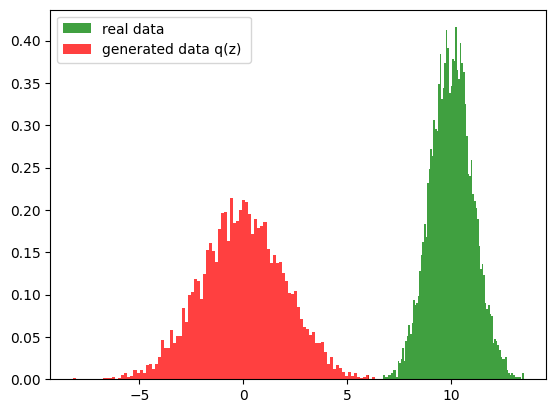

In [38]:
mean = [10]
cov = [[1]]
X = tf.random.normal((5000,1),mean=10,stddev=1.0)

print("mean:",np.mean(X))
print("standard deviation:",np.std(X))

Z = tf.random.normal((5000,1),mean=0,stddev=2)

print("mean:",np.mean(Z))
print("standard deviation:",np.std(Z))

plot_distribution(X,Z,discriminator=None,density=True)

Here we have two datasets that are not very similar. Both in position and in width. We can build an extremely rudimentary geerative model by adding 10 to $Z$. 

mean: 9.973708
standard deviation: 2.0009403


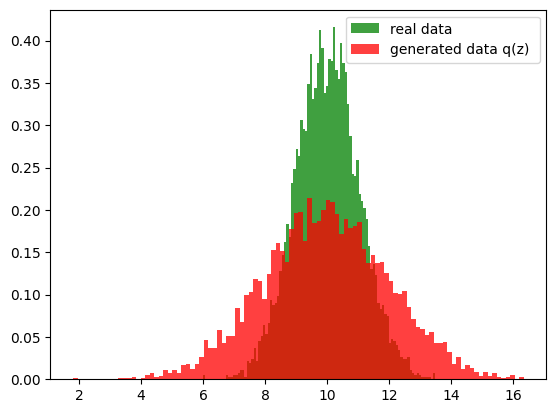

In [39]:
Xhat=Z+10
print("mean:",np.mean(Xhat))
print("standard deviation:",np.std(Xhat))

plot_distribution(X,Xhat,discriminator=None,density=True)

## Building a GAN

### The Generator

Let's first focus on the generator. The idea is that this model can approximate any function due to the Universal Approximation Theorem. The goal will be to transform the input samples $z$ such that it approximates x: $\hat{x} = G(z)$. We can start with a simple generator that provides a linear function: $G(z) = W^T z + b$ (implemented as a single dense layer with 1 neuron and a bias input.)

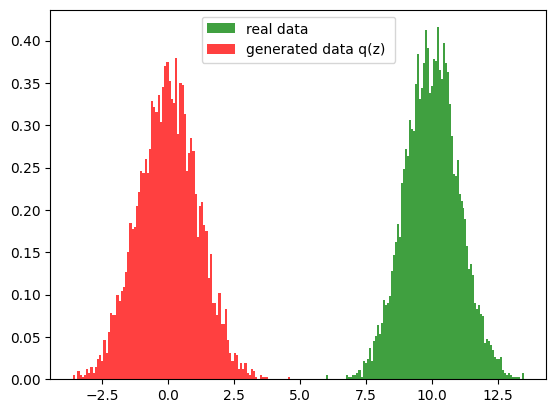

In [40]:
def make_generator_model():
    generator = tf.keras.Sequential()
    generator.add(layers.Dense(1))
    return generator

generator = make_generator_model()

Xhat = generator(Z, training=False)
plot_distribution(real_data=X, generated_data=Xhat)

The model is untrained, so it is not surprising that the distributions are still very different.

### The Discriminator

The other half of the GAN architecture is the discriminator. The simplest discriminator is a logistic regression. We'll start with linear regression and add in the logistic function later as part of the cost function.

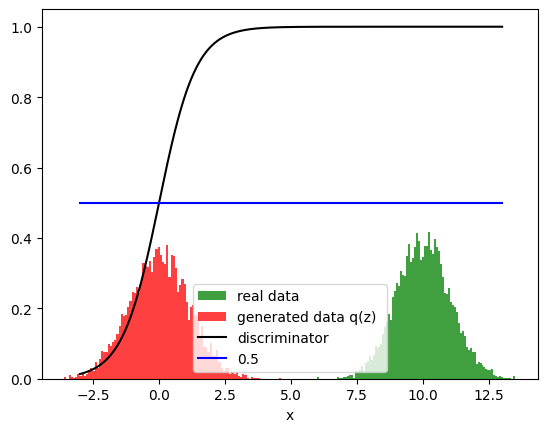

In [50]:
def make_discriminator_model():
    discriminator = tf.keras.Sequential()
    discriminator.add(layers.Dense(1))
    return discriminator

discriminator = make_discriminator_model()

plot_distribution(real_data=X, generated_data=Xhat, discriminator=discriminator)

Since both models are randomly initialised, the output is meaningless at this point. We can still make a comparison as seen above. We also add a threshold, which will be used to determine which class the input data belongs to. If it is above the threshold, then it sill be classified as real data, if it is below the threshold, then it will be classified as generated data.

From this we can already see how the GAN architecture is going to work. 
1. The input to the generator is our fake data $z$.
2. The output of the generator, trying to approximate the real data as good as possible, is being fed into the discriminator.
3. The discriminator decides whether the data is real data or generated data.
4. The loss function then determines how well the entire architecture performs.
5. Updating the weights of the full system then increases the performance of both the generator and the discriminator.

In [51]:
py_x=tf.math.sigmoid(discriminator(X,training=False))
np.sum(py_x>0.5)

np.int64(5000)

In [52]:
py_x=discriminator(Xhat)
np.sum(py_x>0.5)

np.int64(1917)

In [53]:
get_accuracy(X, Xhat)

np.float32(0.7518085)

## The Loss Function

GANs take what is fundamentally an unsupervised problem (learning the structure of data with no labels) and reframe it as a supervised binary classification task. Instead of abstract minimax game theory, you can think of it as: "Can the discriminator tell real from fake?" That's just a two-class classification problem, which we already know how to solve.

### Discriminator

$$V(D)=\sum_{n=1}^N \left( y_n \ln(D(\mathbf{x}_n))+(1-y_n) \ln(1-D(\mathbf{x}_n))\right)$$

This is the log-likelihood of a logistic (binary) classifier, which is mathematically equivalent to minimizing binary cross-entropy (BCE).

So for real samples (y=1), only the first term survives: the discriminator is rewarded for outputting a high probability (close to 1). For fake samples (y=0), only the second term survives: the discriminator is rewarded for outputting a low probability (close to 0).

The discriminator's job is to maximize this value, meaning it wants to:

- Assign high probability to real data
- Assign low probability to generated (fake) data

This is the opposite sign of a typical loss function you'd minimize. Maximizing V(D) is equivalent to minimizing the standard BCE loss — just with the sign flipped. 

Where $y=1$ for samples from the true distribution and $y=0$ for samples from the generator. The goal is to maximize this term with respect to $D$:

$$max_{D}(V(D))$$

To also incorporate the generated samples, we augment the right side of the equation with the generated $k$ th sample $\hat{\mathbf{x}}_k$. As they are not part of the dataset $k \notin \mathcal{D} $, we have to include a second summation where $y=0$. Finally, combining the cases of $y=1$ and $y=0$, we get:

$$V(D)=\sum_{ n	\in \mathcal{D}}  \ln(D(\mathbf{x}_n))+\sum_{k 	\notin \mathcal{D}} \ln(1-D(\hat{\mathbf{x}}_k) ) $$

### Generator

For the generator we simply replace $\hat{\mathbf{x}}\_k$ with the $G(\mathbf{z}\_k)$ .

$$V(G,D)=\sum_{n	\in \mathcal{D}} \ln(D(\mathbf{x}_n))+\sum_{k 	\notin \mathcal{D}} \ln(1-D(G(\mathbf{z}_k))) $$

As this is a density estimation problem, it is common to replace the summation with the expected value like in <a href=https://arxiv.org/pdf/1406.2661.pdf >Generative Adversarial Nets</a>. We replace the summations with an expectation where $p(\mathbf{x})$ is the true distribution and $p(\mathbf{z})$ is the distribution of $\mathbf{z}$.

$$V(D,G)=\mathbb{E}_{\mathbf{x}\sim p(\mathbf{x})} \ln(D(\mathbf{x})) + \mathbb{E}_{\mathbf{z} \sim p(\mathbf{z})} \ln(1-D(G(\mathbf{z}) )) $$

As we are trying to trick the discriminator, we would like to find a $G$ that minimize the above expression, such as:

$$min_{G} max_{D} V(D,G)$$

### Adversarial

Here's why it's called adversarial:

- The discriminator wants real samples to look "real" (high D(x)) and fakes to look "fake" (low D(G(z)))
- The generator wants its outputs to look "real" (high D(G(z))) to minimize the discriminator's objective
- They're playing against each other — one's gain is the other's loss

At equilibrium (ideally):

- The generator learns to produce samples indistinguishable from real data
- The discriminator can't tell the difference anymore, outputting D(G(z)) ≈ 0.5 (maximum uncertainty)

## Training GANs

### Training Generator

GANs are quite difficult to train, even for a simple example. Let's start off with training the generator in practice.

$log(1 − D(G(\mathbf{z})))$ is difficult to work with as $D(G(\mathbf{z}))$ is near one or zero for the first few iterations. This is because the generator is not yet properly trained, and the discriminator can easily distinguish between the generated and actual samples. Therefore we maximize $log(D(G(\mathbf{z}_k)) )$.

Although the output of the generator passes through the discriminator, we do not update the generator in the optimization step, hence we set the parameter `training=False` in the actual training steps.

Instead of maximizing the term, we can take the negative and minimize it. The resultant expression can be calculated in Keras using the cross-entropy loss where all the target values are set to one:

$$\sum\_{k 	\notin \mathcal{D}} log(1 - D(G(\mathbf{z}_k)) )$$


In [54]:
# This method returns a helper function to compute crossentropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def generator_loss(Xhat):
    return cross_entropy(tf.ones_like(Xhat), Xhat)

### Training Discriminator

We can also use the cross-entropy to train the discriminator; we simply multiply $V(G,D)$ by a negative number, set $y=0$ for the generated values and $y=1$ for the real values. We do not update the generator parameters.

$$V(G)=\sum_{n \in \mathcal{D}} \ln(D(\mathbf{x}_n))+\sum_{k \notin \mathcal{D}} \ln(1-D(G(\mathbf{z}_k) )) $$

In [55]:
def discriminator_loss(X, Xhat):
    real_loss = cross_entropy(tf.ones_like(X), X)
    fake_loss = cross_entropy(tf.zeros_like(Xhat), Xhat)
    total_loss = 0.5*(real_loss + fake_loss)
    return total_loss

generator_optimizer = tf.keras.optimizers.Adam(5e-1,beta_1=0.5,beta_2=0.8)
discriminator_optimizer = tf.keras.optimizers.Adam(5e-1,beta_1=0.5, beta_2=0.8)

We now train the model; as the dataset is small, we will use batch gradient descent.

For each iteration we will generate $M$ real examples ${\mathbf{x}_{1}, ...,\mathbf{x}_{M}}$, these are from the generating distribution $p(\mathbf{x})$. This would be our actual dataset if we used real data.

We will then generate a sample batch of $M$ noise samples ${\mathbf{z}_{1}, ...,\mathbf{z}_{M}}$ from noise prior $p(\mathbf{z})$ and convert the result to a generated image using the generator ${\hat{\mathbf{x}}_{1}, ...,\hat{\mathbf{x}}_{M}}$.

We determine the output of the discriminator for both the real and generated samples. We calculate the loss and then update the discriminator and generator through their respective stochastic gradients.

The convergence of GAN training is a subject in itself. But let's explore a method that works for this simple dataset. Intuitively, we know that if our generated data is identical to our actual data, the probability of correctly classifying is random. Therefore if the generated and actual data are of equal proportion, $D(\mathbf{x}_n)=0.5$ and $D(\hat{\mathbf{x}}_n)=0.5$.

We only display iterations where the average discriminator output gets closer to 50% for both the generated data and actual data.


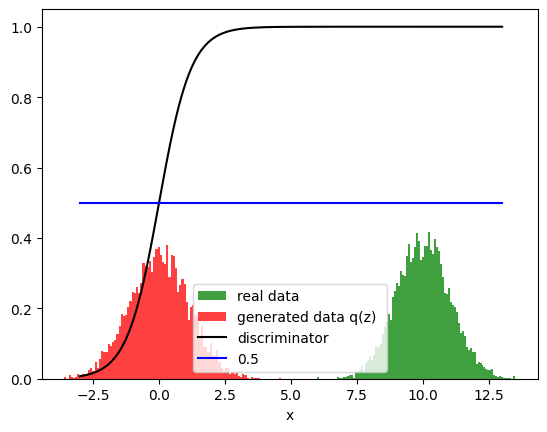

epoch 0


  0%|          | 0/20 [00:00<?, ?it/s]


ValueError: Unknown variable: <Variable path=sequential_15/dense_15/kernel, shape=(1, 1), dtype=float32, value=[[1.0700935]]>. This optimizer can only be called for the variables it was originally built with. When working with a new set of variables, you should recreate a new optimizer instance.

In [57]:
#paramters for trainng 
epochs=20
BATCH_SIZE=5000
noise_dim=1
epsilon=100 

#discrimator and generator 
tf.random.set_seed(0)
discriminator = make_discriminator_model()
generator = make_generator_model()
tf.config.run_functions_eagerly(True)

gen_loss_epoch = []
disc_loss_epoch = []
plot_distribution(real_data=X, generated_data=Xhat, discriminator=discriminator)
print("epoch", 0)

for epoch in tqdm(range(epochs)):
    #data for the true distribution of your real data samples training ste
    x = tf.random.normal((BATCH_SIZE,1),mean=10,stddev=1.0)
    #random samples it was found if you increase the  stander deviation, you get better results 
    z= tf.random.normal([BATCH_SIZE, noise_dim],mean=0,stddev=10)
    # needed to compute the gradients for a list of variables.
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        #generated sample 
        xhat = generator(z, training=True)
        #the output of the discriminator for real data 
        real_output = discriminator(x, training=True)
        #the output of the discriminator  data
        fake_output = discriminator(xhat, training=True)
        #loss for each 
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    # Compute the gradients for gen_loss and generator
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    # Compute the gradients for gen_loss and discriminator
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    # Ask the optimizer to apply the processed gradients
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
  
  # Save and display the generator and discriminator if the performance increases 
    if abs(0.5-get_accuracy(x,xhat))<epsilon:
        epsilon = abs(0.5-get_accuracy(x,xhat))
        # generator.save('generator')
        # discriminator.save('discriminator')
        print(get_accuracy(x,xhat))
        plot_distribution(real_data=X,generated_data=xhat,discriminator=discriminator )
        print("epoch",epoch)

In [ ]:
generator = make_generator_model()
generator = models.load_model('generator')
xhat = generator(z)
discriminator = models.load_model('discriminator')
plot_distribution(real_data=X, generated_data=xhat, discriminator=discriminator)

### Resources

- [Intuitive Introduction to GANs](https://medium.com/data-science/intuitive-introduction-to-generative-adversarial-networks-gans-230e76f973a9)
- [Decoding GAN Math](https://towardsdatascience.com/decoding-the-basic-math-in-gan-simplified-version-6fb6b079793/)
- [Why is it hard to train GANs](https://jonathan-hui.medium.com/gan-why-it-is-so-hard-to-train-generative-advisory-networks-819a86b3750b)